#                                                               Retail Sales Analysis


##  Project Overview

#### This project analyzes retail sales data to uncover key business insights such as top-performing products, cities, managers, and seasonal sales trends.  
#### The goal is to help stakeholder identify where to focus efforts to drive growth.



### Key Steps

#### Data Cleaning- Removed duplicates, Fixed missing values and text inconsistencies, corrected data types (dates, numeric columns)

#### Exploratory Data Analysis (EDA)- Aggregated sales by product, manager, payment method, region, and time, Identified seasonal trends and revenue distribution

#### Visualization- Created bar and line charts to highlight sales patterns for better insight communication

### Importing pandas and loading the data

In [5]:
import pandas as pd
import numpy as np

In [6]:
# Load the excel file
df=pd.read_excel('Python_SalesData (1).xlsx')

In [9]:
# Preview the data
df.head(5)


,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
1,NaN,10452,2022-11-07 00:00:00,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
2,NaN,10453,2022-11-07 00:00:00,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
3,NaN,10454,2022-11-07 00:00:00,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
4,NaN,10455,2022-11-08 00:00:00,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin


# Data Cleaning

In [10]:
# Fixing Column Headers
df=pd.read_excel('Python_SalesData (1).xlsx', header=1)

In [11]:
df.head()

,Unnamed: 0,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,NaN,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
1,NaN,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
2,NaN,10454,2022-11-07,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
3,NaN,10455,2022-11-08,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
4,NaN,10456,2022-11-08,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin


In [12]:
#Deleting the empty (Unnamed column
)df=df.drop(columns=['Unnamed: 0'])

In [13]:
df.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin


In [15]:
# fixing the extra spaces and turning the column names to lowercase
df.columns=df.columns.str.strip().str.lower().str.replace(' ','_')

In [16]:
df.head()

,order_id,date,product,price,quantity,purchase_type,payment_method,manager,city
0,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin


### Checking the Dataset

In [17]:
#The no of rows and columns
df.shape

(254, 9)

In [18]:
#Total rows in the dataset
df.size

2286

In [19]:
# The statics of the dataset
df.describe()

,order_id,date,price,quantity
count,254.000000,254,254.000000,254.000000
mean,10584.133858,2022-12-03 10:23:37.322834688,7.102323,460.610541
min,10452.000000,2022-11-07 00:00:00,2.950000,200.400802
25%,10520.250000,2022-11-21 00:00:00,3.490000,201.005025
50%,10583.500000,2022-12-03 00:00:00,4.990000,538.876059
75%,10649.750000,2022-12-16 18:00:00,9.950000,677.444188
max,10713.000000,2022-12-29 00:00:00,29.050000,754.426482
std,75.889181,NaN,4.341855,214.889551


In [34]:
# The datatypes of the dataset
df.dtypes


order_id                   int64
date              datetime64[ns]
product                   object
price                    float64
quantity                 float64
purchase_type             object
payment_method            object
manager                   object
city                      object
dtype: object

In [35]:
# Checking for null values
df.isnull().sum()

order_id          0
date              0
product           0
price             0
quantity          0
purchase_type     0
payment_method    0
manager           0
city              0
dtype: int64

In [36]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        254 non-null    int64         
 1   date            254 non-null    datetime64[ns]
 2   product         254 non-null    object        
 3   price           254 non-null    float64       
 4   quantity        254 non-null    float64       
 5   purchase_type   254 non-null    object        
 6   payment_method  254 non-null    object        
 7   manager         254 non-null    object        
 8   city            254 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 18.0+ KB


In [21]:
# Checking for duplicate
df.duplicated().any()

np.False_

In [20]:
#Preview the dataset
df.head()

,order_id,date,product,price,quantity,purchase_type,payment_method,manager,city
0,10452,2022-11-07,Fries,3.49,573.065903,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,Beverages,2.95,745.762712,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,Sides & Other,4.99,200.400802,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,Burgers,12.99,569.668976,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,Chicken Sandwiches,9.95,201.005025,In-store,Credit Card,Walter Muller,Berlin


In [22]:
#Changing the datatypes - quantity column from float to integer
df['quantity']=df['quantity'].astype(int)

In [23]:
#Previewing the dataset
df.head()


,order_id,date,product,price,quantity,purchase_type,payment_method,manager,city
0,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
1,10453,2022-11-07,Beverages,2.95,745,Online,Gift Card,Pablo Perez,Madrid
2,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon
3,10455,2022-11-08,Burgers,12.99,569,In-store,Credit Card,Walter Muller,Berlin
4,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin


### Checking for Text Inconsistencies - Text extra spaces, Incorrect spellings

In [24]:
# Check for text incosistency in the product column
print(df['product'].unique())

['Fries' 'Beverages' 'Sides & Other' 'Burgers' 'Chicken Sandwiches']


In [25]:
# Check for text incosistency in the manager column
print(df['manager'].unique())

['Tom      Jackson' '       Pablo Perez' 'Joao    Silva' 'Walter Muller'
 'Remy    Monet' 'Remy Monet' '       Remy Monet' 'Remy     Monet'
 'Pablo Perez' 'Pablo   Perez' 'Pablo  Perez' 'Pablo    Perez'
 'Joao Silva' 'Tom Jackson']


In [26]:
# Check for text incosistency in the city column
print(df['city'].unique())

['London' 'Madrid' 'Lisbon' 'Berlin' 'Paris']


In [27]:
# Check for text incosistency in the purchase_type column
print(df['purchase_type'].unique())

['Online ' 'In-store ' 'Drive-thru ']


In [28]:
## Check for text incosistency in the payment_method column
print(df['payment_method'].unique())

[' Gift Card' ' Credit Card' ' Cash']


### Fixing Text inconsistencies - Text extra spaces

In [29]:
# removing the extra spaces in the text strings
df['manager']=( df['manager'].str.strip().str.replace(r'\s+', ' ', regex=True).str.title())

In [30]:
print(df['manager'].unique())

['Tom Jackson' 'Pablo Perez' 'Joao Silva' 'Walter Muller' 'Remy Monet']


In [31]:
df['purchase_type']=( df['purchase_type'].str.strip())

In [32]:
print(df['purchase_type'].unique())

['Online' 'In-store' 'Drive-thru']


In [33]:
df['payment_method']=( df['payment_method'].str.strip())

In [34]:
print(df['payment_method'].unique())

['Gift Card' 'Credit Card' 'Cash']


### Checking for Outliers

In [35]:
#import the matplot library

import matplotlib.pyplot as plt

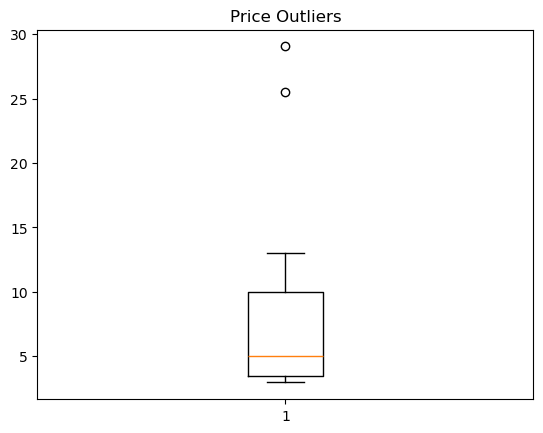

In [36]:
#plotting the boxplot to identity the outliers

plt.boxplot(df['price'])
plt.title('Price Outliers')
plt.show()

In [37]:
# identifying which row that  has the outlier in the dataset which was row 28 and 29
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["price"] < lower) | (df["price"] > upper)]
print(outliers)


    order_id       date             product  price  quantity purchase_type  \
28     10482 2022-11-13               Fries  25.50       630      In-store   
29     10486 2022-11-14  Chicken Sandwiches  29.05       201      In-store   

   payment_method     manager    city  
28    Credit Card  Joao Silva  Lisbon  
29    Credit Card  Joao Silva  Lisbon  


### Handling Outliers by replacing with the Median

In [38]:
#Replacing the outlier on the row 28 and 29 with median of the price
median_price=df['price'].median()
df.loc[[28,29],'price']=median_price

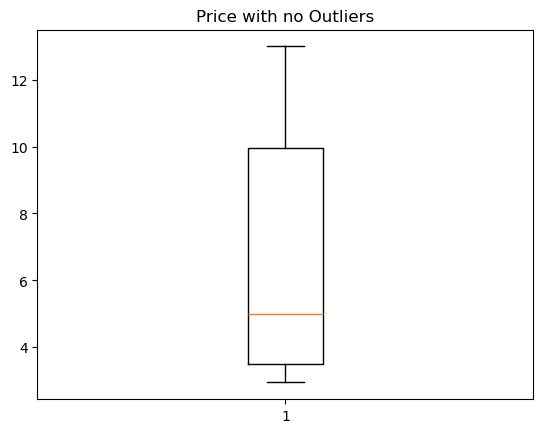

In [39]:
# Plotting box plot to show if there is no outliers
plt.boxplot(df['price'])
plt.title('Price with no Outliers')
plt.show()

# Exploratory Data Analysis- EDA

In [85]:
# Key Performance Indicators (KPI)

# Total Revenue
total_sales = (df['price'] * df['quantity']).sum()

# Total Orders
total_orders = df['order_id'].nunique()

# Total Quantity Sold
total_quantity = df['quantity'].sum()

# Average Order Value (AOV)
avg_order_value = total_sales / total_orders

#  Print KPI Summary
print("Key Performance Indicators")
print(f" Total Revenue: ${total_sales:,.2f}")
print(f" Total Orders: {total_orders:,}")
print(f" Total Quantity Sold: {total_quantity:,}")
print(f" Average Order Value: ${avg_order_value:,.2f}")





Key Performance Indicators
 Total Revenue: $751,074.42
 Total Orders: 254
 Total Quantity Sold: 116,882
 Average Order Value: $2,956.99


#### 1. What was the Most Preferred Payment Method?

The most preferred payment method is: Credit Card


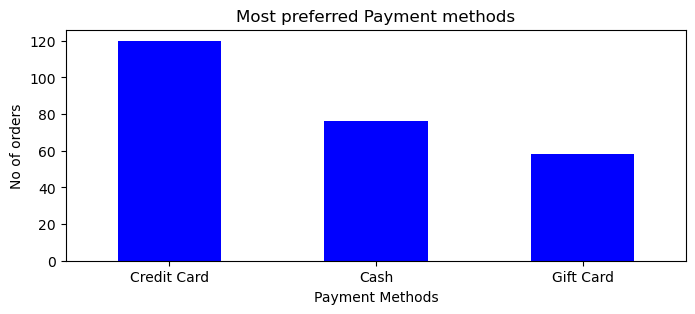

In [66]:
payment_counts=df['payment_method'].value_counts()
most_preferred = payment_counts.idxmax()
print("The most preferred payment method is:", most_preferred)
bars=payment_counts.plot(kind='bar', color='blue', figsize=(8,3))
plt.title('Most preferred Payment methods')
plt.xlabel('Payment Methods')
plt.ylabel('No of orders')
plt.xticks(rotation=0)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

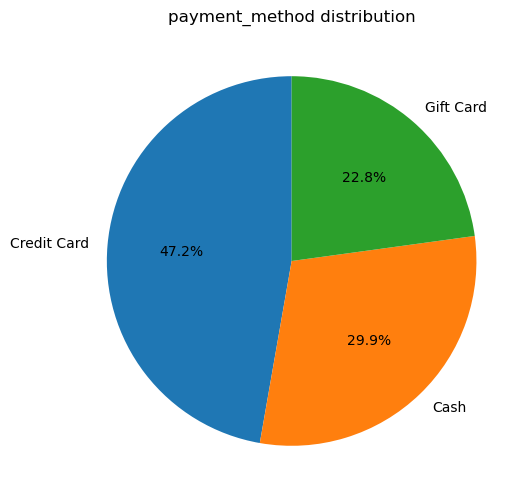

In [72]:
import matplotlib.pyplot as plt
payment_counts=df['payment_method'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(payment_counts,labels=payment_counts.index, autopct= '%1.1f%%', startangle=90)
plt.title('payment_method distribution')
plt.show

#### 2. Which one was the Most Selling Product by Quantity and by Revenue?

The most selling product by quantity is: Beverages


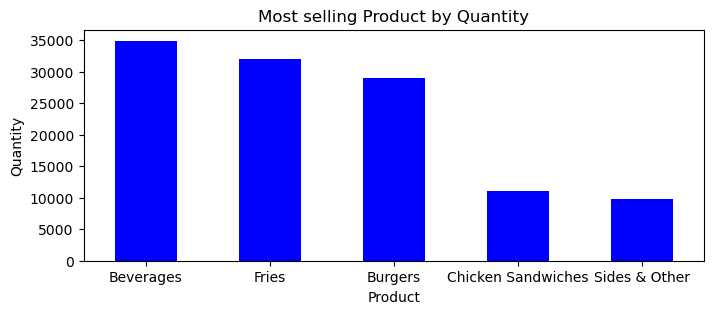

In [50]:
selling_qty=df.groupby("product")["quantity"].sum().sort_values(ascending=False)
most_selling_qty= selling_qty.idxmax()
print("The most selling product by quantity is:", most_selling_qty)

bars=selling_qty.plot(kind='bar', color='blue', figsize=(8,3))
plt.title('Most selling Product by Quantity')
plt.xlabel('Product')
plt.ylabel('Quantity')
plt.xticks(rotation=0)
plt.show()


##### Creating revenue column

The most selling by product by revenue is: Burgers


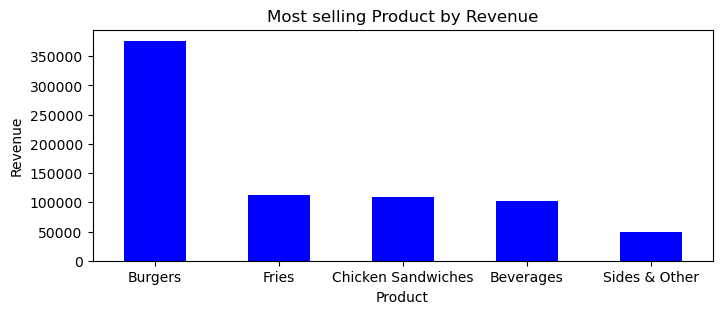

In [88]:
# Creating the revenue column by multiplying the quantity column by price column
df['revenue'] = df['quantity']* df['price']
selling_rev= df.groupby("product")["revenue"].sum().sort_values(ascending=False)
most_selling_rev =selling_rev.idxmax()
print("The most selling by product by revenue is:", most_selling_rev)

# Plotting bar chart 
bars=selling_rev.plot(kind='bar', color='blue', figsize=(8,3))
plt.title('Most selling Product by Revenue')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()


#### 3. Which City had maximum revenue, and Which Manager earned maximum revenue?

City with the maximum revenue is: Lisbon


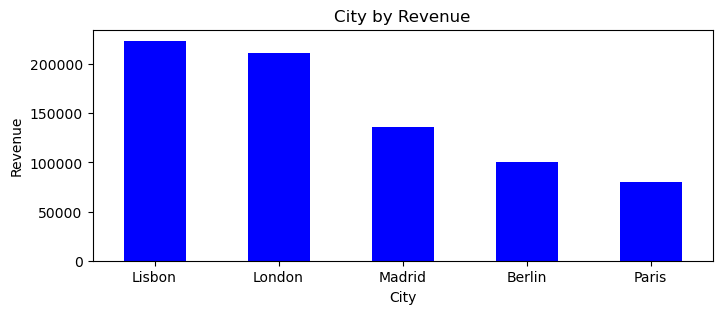

In [89]:
# Grouping the city by revenue generated
city_revenue = df.groupby("city")["revenue"].sum().sort_values(ascending=False)
max_city= city_revenue.idxmax()
print("City with the maximum revenue is:",max_city)

# Plotting the bar chart
bars=city_revenue.plot(kind='bar', color='blue', figsize=(8,3))
plt.title('City by Revenue')
plt.xlabel('City')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()


##### Manager with maximum earned revenue

The manager with the maximum earned revenue is: Joao Silva


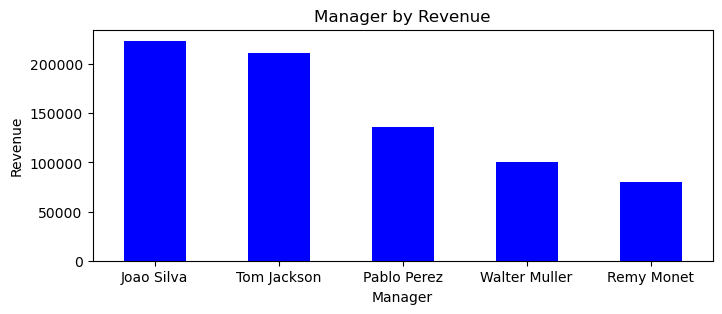

In [91]:
manager_revenue =df.groupby("manager")["revenue"].sum().sort_values(ascending=False)
manager_max_revenue= manager_revenue.idxmax()
print("The manager with the maximum earned revenue is:",manager_max_revenue)

# Ploting bar chart 
bars=manager_revenue.plot(kind='bar', color='blue', figsize=(8,3))
plt.title('Manager by Revenue')
plt.xlabel('Manager')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()


The manager & city with the maximum earned revenue is: ('Joao Silva', 'Lisbon')
Total Revenue: $223,752.02


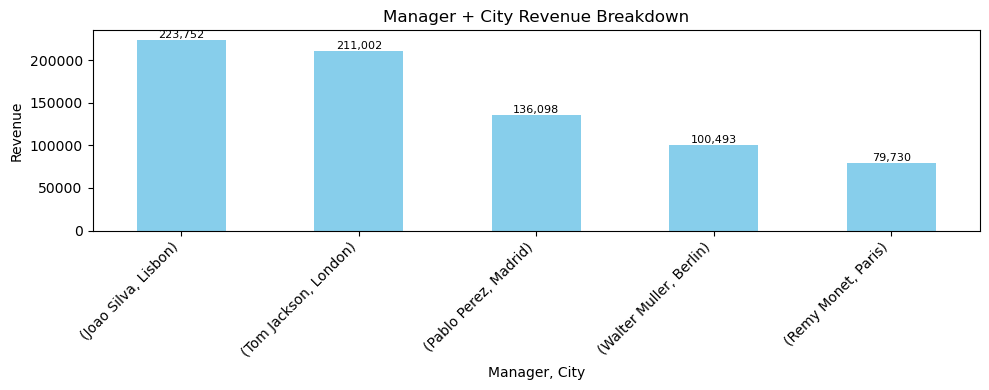

In [96]:


# Group by manager and city, sum revenue, and sort descending
manager_crevenue = (
    df.groupby(["manager", "city"])["revenue"]
    .sum()
    .sort_values(ascending=False)
)

# 

print("The manager & city with the maximum earned revenue is:", manager_max_crevenue)
print(f"Total Revenue: ${max_value:,.2f}")

# Plotting
plt.figure(figsize=(10, 4))
bars = manager_crevenue.plot(kind='bar', color='skyblue')

# Title and labels
plt.title('Manager + City Revenue Breakdown')
plt.xlabel('Manager, City')
plt.ylabel('Revenue')
plt.xticks(rotation=45, ha='right')  # Rotate x-labels for readability

# Annotate bars with revenue values
for bar in bars.patches:
    bars.annotate(
        f'{bar.get_height():,.0f}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center', va='bottom', fontsize=8, rotation=0
    )

plt.tight_layout()
plt.show()



#### 4. What was the Average Revenue?

In [99]:
average_rev= df["revenue"].mean().round(2)
print("The average revenue was:", average_rev)

The average revenue was: 2956.99


#### 5. What was the Average Revenue of November & December?

In [58]:
nov_date= df[(df['date']>='2022-11-01')& (df['date']<='2022-11-30')]
dec_date =df[(df['date']>='2022-12-01') & (df['date']<='2022-12-31')]
average_nov_rev= nov_date["revenue"].mean().round(2)
average_dec_rev= dec_date["revenue"].mean().round(2)
print("The average revenue of November was ",average_nov_rev,"and December was ", average_dec_rev)

The average revenue of November was  2779.51 and December was  3099.22


#### 6. What was the Standard Deviation of Revenue and Quantity?

In [59]:
SD_of_revenue= round(df["revenue"].std(), 2)
SD_of_quantity= round(df["quantity"].std(), 2)

print("The standard deviation of revenue was", SD_of_revenue,"and Quantity was",SD_of_quantity)

The standard deviation of revenue was 2270.65 and Quantity was 214.69


#### 7. What was the Variance of Revenue and Quantity?

In [143]:
var_of_rev= round(df["revenue"].var(), 2)
var_of_qty= round(df["quantity"].var(), 2)

print("The variance of revenue was",var_of_rev,"and quantity was",var_of_qty)

#### 8. Was the revenue increasing or decreasing over the time?

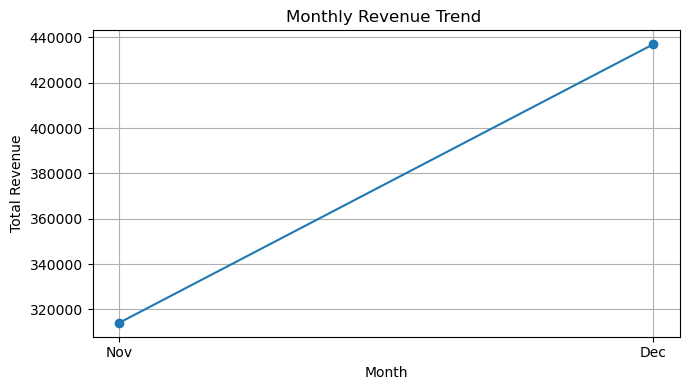

In [61]:

import matplotlib.pyplot as plt
#  1. Create month number and month name columns
df['month_num'] = df['date'].dt.month
df['month'] = df['date'].dt.strftime('%b') 

# 2. Group data by month (aggregate revenue)
monthly_revenue = df.groupby('month_num', as_index=False)['revenue'].sum()

# 3. Map month number to proper order (Jan → Dec)
monthly_revenue['month'] = monthly_revenue['month_num'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# 4. Plot monthly revenue
plt.figure(figsize=(7, 4))
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'], marker='o', linestyle='-')

# 5. Chart labels & styling
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend ")
plt.grid(True)
plt.tight_layout()

# 6. Show chart
plt.show()


#### 9. What was the Average 'Quantity Sold' & 'Average Revenue' for each product?

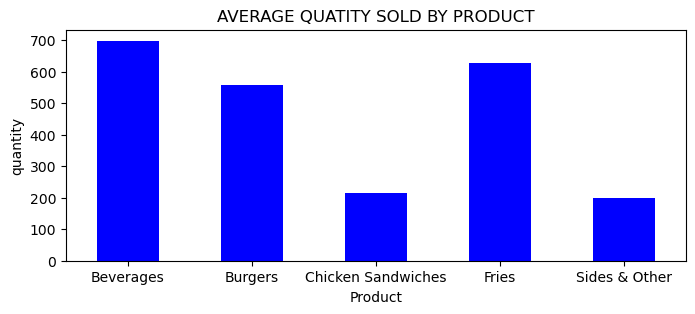

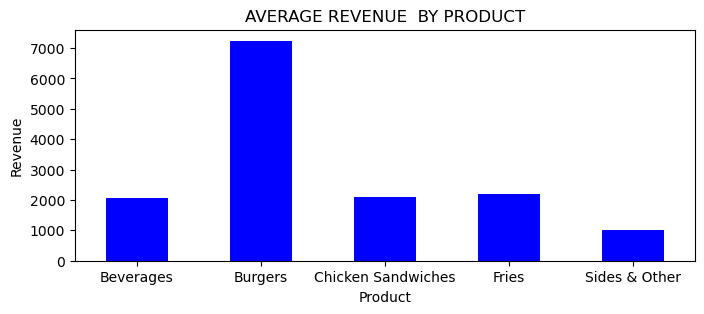

In [65]:
avg_qty_product = df.groupby("product")["quantity"].mean().round(2)
avg_revenue_product = df.groupby("product")["revenue"].mean().round(2)

# Ploting bar chart 
bars= avg_qty_product.plot(kind='bar', color='blue', figsize=(8,3))
plt.title('AVERAGE QUATITY SOLD BY PRODUCT')
plt.xlabel('Product')
plt.ylabel('quantity')
plt.xticks(rotation=0)
plt.show()

# Ploting bar chart for revenue 
bars= avg_revenue_product.plot(kind='bar', color='blue', figsize=(8,3))
plt.title('AVERAGE REVENUE  BY PRODUCT')
plt.xlabel('Product')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.show()



#### 10. What was the total number of orders or sales made?

In [177]:
total_number_of_order=df["order_id"].count()
print("The total number of orders made :",total_number_of_order)


The total number of orders made : 254


##  KPIs Summary
- **Total Revenue:** $751,074
  
- **Total Orders:** 254
  
- **Total Units Sold:** 116,882
  
- **Average Order Value (AOV):** $2,596  



##  Key Insights 

###  Top Drivers
- **Top City:** **Lisbon** – contributed **$224K** (≈30% of total revenue)
  
- **Top Manager:** **Joao Silva** – achieved **$224K** revenue managing Lisbon

  
- **Top Product (Revenue):** **Burgers** – generated **$377K** (≈50% of total revenue)


- **Top Product (Units Sold):** **Beverages** – **34,938 units** sold

###  Trends & Customer Behavior
- **Seasonal Peak:** **December** recorded the **highest monthly revenue**, confirming strong year-end demand
- **Payment Preference:** **47.2%** of transactions were made via **credit card**, showing a strong preference for digital payment methods



##  Recommendations

- **Replicate Success in Other Cities:** Analyze Lisbon’s strategy (pricing, promotions, customer behavior) and apply to underperforming regions.  
- **Leverage Top Manager Performance:** Use Joao Silva’s approach as a best-practice model for training and performance improvement.  
- **Bundle & Promote Burgers:** Create burger + beverage combos to boost revenue and cross-sell lower-margin products.  
- **Prepare for December Demand:** Increase inventory and marketing campaigns ahead of the holiday season.  
- **Introduce Payment Incentives:** Offer discounts or points for credit card payments to encourage repeat purchases.













##  Tools & Techniques Used
- **Python:** pandas, matplotlib  
- **Analysis:** Data cleaning, grouping, aggregation, KPI calculation  
- **Visualization:** Bar charts, pie charts, trend lines  







In [100]:
df.to_excel('sales_data_python.xlsx', index=False)